## Import Required Libraries

In [90]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Task 1 — Data Loading & Exploration**

In [91]:
df = pd.read_csv("Housing.csv")
df.head(10) #Printing the first 10 rows of Housing.csv file.

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [92]:
print(f"Rows : {df.shape[0]} , Columns : {df.shape[1]}") #Printing the Shape of Dataset, No of Rows and Coloumns.

Rows : 545 , Columns : 13


In [93]:
# Show dataset information
df.info()

# Print target and feature columns
print("Target column : price")
print("Feature columns:", [col for col in df.columns if col != 'price'])

# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
Target column : price
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioni

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## **Task 2 — Data Cleaning**

In [94]:
# Fill missing values in the dataset
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            # Use the most common value for categorical columns
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            # Use the median value for numerical columns
            df[col] = df[col].fillna(df[col].median())

# Verify that no missing values remain
print("Missing values after handling:\n", df.isnull().sum().sum())

Missing values after handling:
 0


In [95]:
# Check duplicates
print(f"Duplicates found: {df.duplicated().sum()}")

# Remove duplicates
df = df.drop_duplicates()

# Updated dataset size
print(f"Shape after removing duplicates: {df.shape}")

Duplicates found: 0
Shape after removing duplicates: (545, 13)


In [96]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", categorical_cols)

# Convert categorical data into numerical form(Encoding)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows
df_encoded.head()

# Show updated column names
print(df_encoded.columns.tolist())

Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


## **Task 3 — Model Building**

In [97]:
# Separate features and target variable
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Split the data into training and testing sets(80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Create train and test datasets
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

# Save datasets as CSV files
train_data.to_csv("train_data.csv", index=False)
test_data.to_csv("test_data.csv", index=False)

# Display dataset shapes
print("Train dataset shape:", train_data.shape)
print("Test dataset shape:", test_data.shape)

# Show train-test split sizes
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train dataset shape: (436, 14)
Test dataset shape: (109, 14)
Train size: 436, Test size: 109


## Linear Regression

In [98]:
# Train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on test data
lr_preds = lr_model.predict(X_test)

# Calculate evaluation metrics
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

# Display model performance
print("Linear Regression:")
print(f"MAE: {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R² Score: {lr_r2:.4f}")

Linear Regression:
MAE: 970043.40
RMSE: 1324506.96
R² Score: 0.6529


## Random Forest

In [99]:
# Train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on test data
rf_preds = rf_model.predict(X_test)

# Calculate performance metrics
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

# Display model performance
print("Random Forest Regressor:")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.4f}")

Random Forest Regressor:
MAE: 1013968.58
RMSE: 1398115.67
R² Score: 0.6133


In [100]:
# Compare the performance of both models
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R² Score': [lr_r2, rf_r2]
})

# Display comparison table
comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.013969e+06,1.398116e+06,0.613275


## **Task 4 — Visualization**

In [101]:
# Set a clean plot style
sns.set_style('whitegrid')

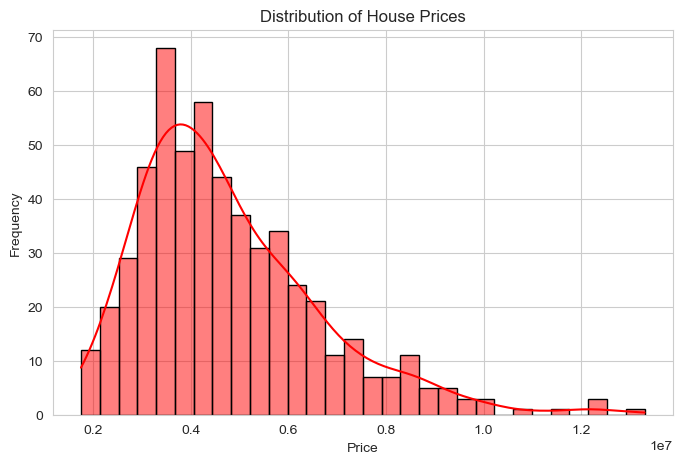

In [102]:
# Plot the distribution of house prices
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True, color='red', edgecolor='black')

# Add chart title and labels
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

# Display the plot
plt.show()

## Correlation Heatmap of Features

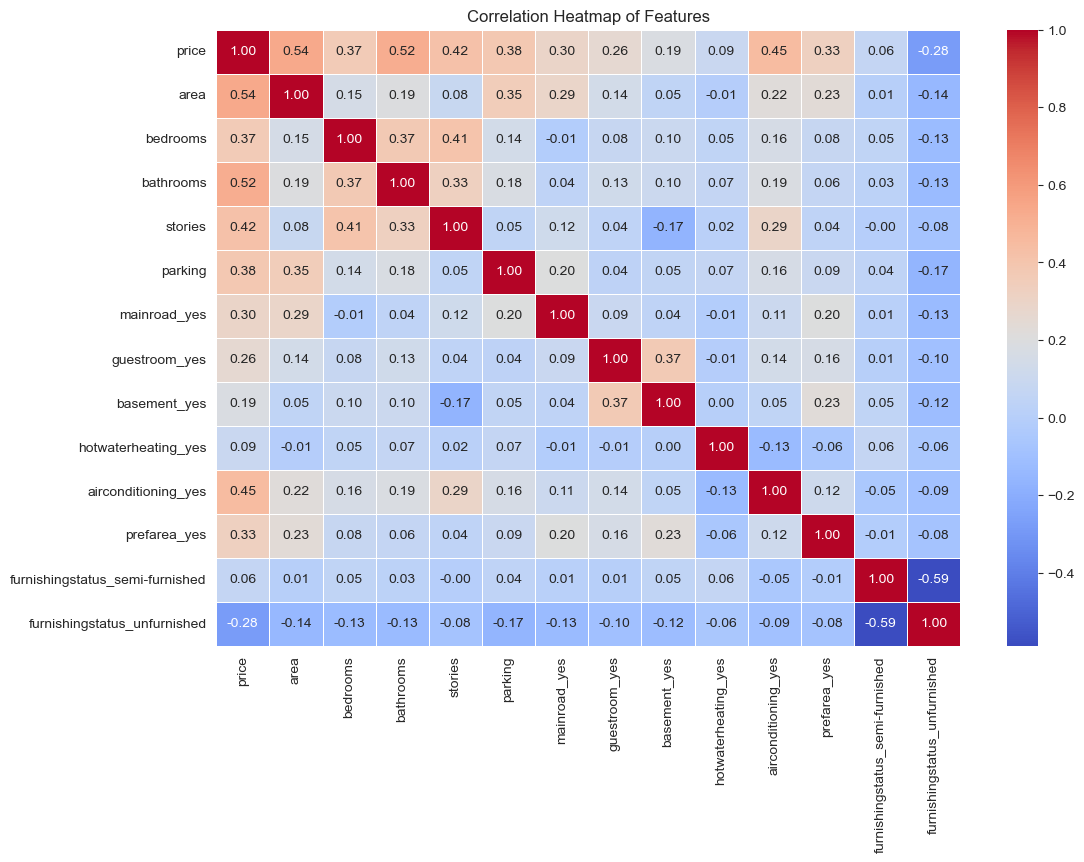

In [103]:
# Calculate correlation between all features
plt.figure(figsize=(12,8))
corr = df_encoded.corr()

# Create correlation heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

# Add title
plt.title('Correlation Heatmap of Features')

# Display the plot
plt.show()

The correlation heatmap shows that area (0.54) and bathrooms (0.52) have the strongest positive relationship with house price, indicating that larger houses with more bathrooms tend to be more expensive. Features such as air conditioning (0.45), stories (0.42), and parking (0.38) also contribute positively to price. In contrast, unfurnished houses (-0.28) show a negative correlation with price, suggesting that unfurnished properties are generally less expensive than furnished ones.

## Boxplot Analysis of House Prices by Furnishing Status

<Axes: xlabel='furnishingstatus', ylabel='price'>

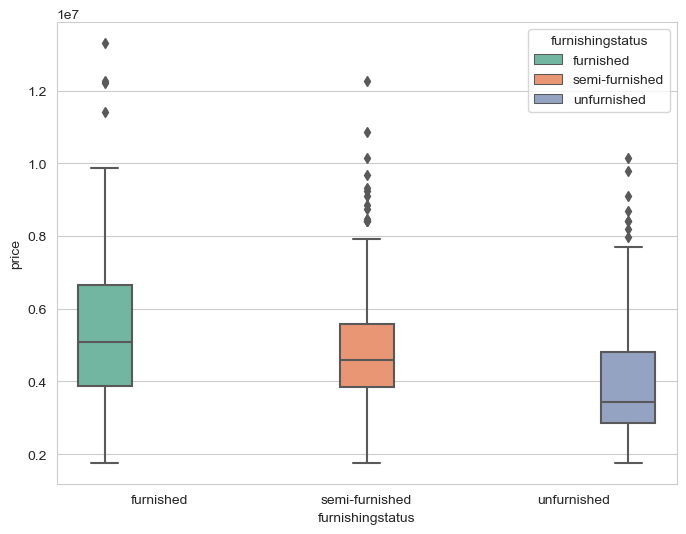

In [104]:
# Compare house prices across furnishing categories
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='furnishingstatus',
    y='price',
    hue='furnishingstatus',
    palette='Set2'
)


The boxplot indicates that house prices generally increase with the level of furnishing. Furnished houses tend to have the highest prices, followed by semi-furnished houses, while unfurnished houses are usually the most affordable. A few high-priced outliers can also be seen in all categories, showing that some properties are significantly more expensive than the majority of houses in the dataset.

## Actual vs Predicted House Prices (Linear Regression)

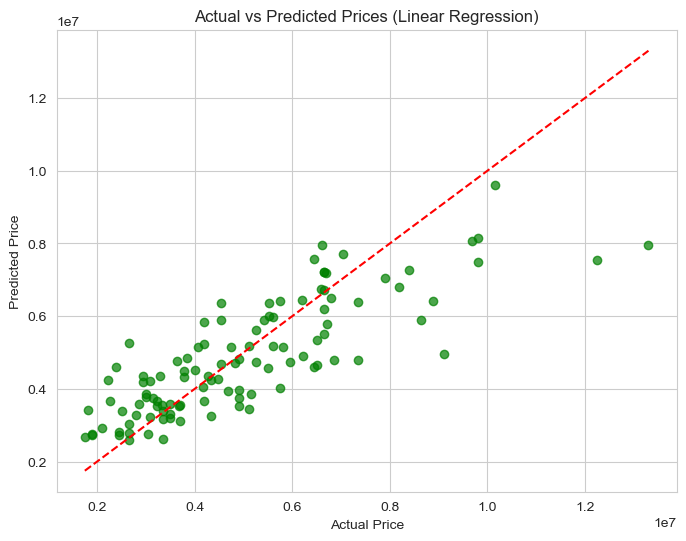

In [105]:
# Compare actual and predicted house prices
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_preds, alpha=0.7, color='green')

# Add reference line for perfect predictions
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

# Add labels and title
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Linear Regression)")

# Display the plot
plt.show()

## Actual vs Predicted House Prices (Random Forest)

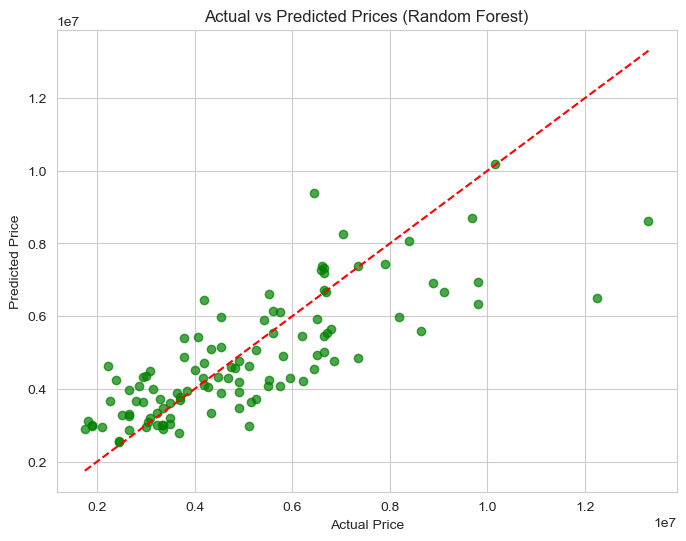

In [106]:
# Compare actual and predicted house prices
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_preds, alpha=0.7, color='green')

# Add reference line for perfect predictions
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

# Add labels and title
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Random Forest)")

# Display the plot
plt.show()

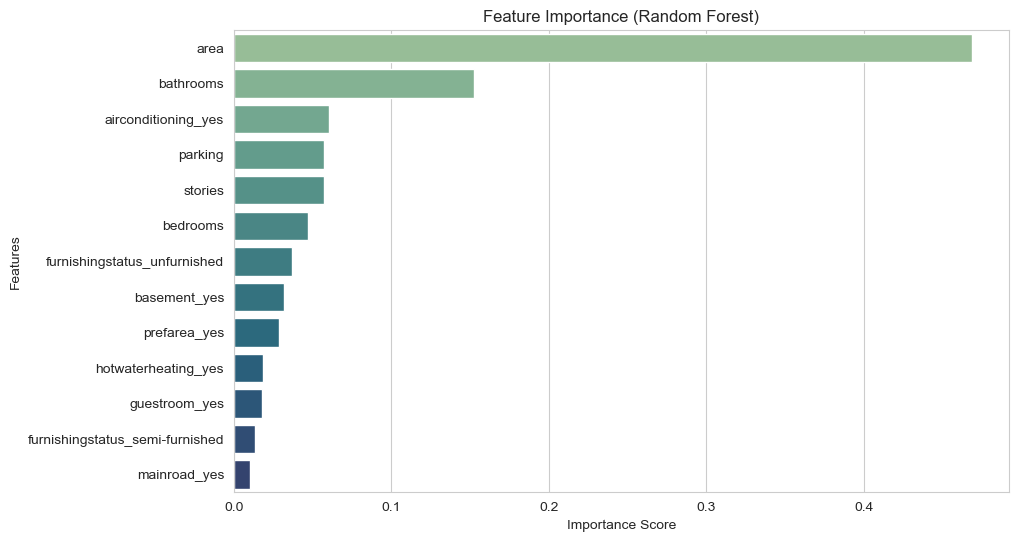

In [107]:
# Calculate feature importance scores
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Plot feature importance
plt.figure(figsize=(10,6))

sns.barplot(
    x=importances.values,
    y=importances.index,
    palette='crest'
)

# Add labels and title
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')

# Display the plot
plt.show()

**Task 5 — Insights & Summary**

The analysis showed that area and bathrooms have the strongest influence on house price. The Random Forest feature importance chart also highlighted area as the most important feature, followed by bathrooms, air conditioning, parking, and stories. One interesting finding was that the number of bedrooms had less impact on price than expected.

Among the two models, Linear Regression performed slightly better than Random Forest, achieving an R² score of about 0.65. This means the model was able to explain around 65% of the variation in house prices. The average prediction error was approximately ₹9.7 lakh, which indicates that the model(LR) can provide a reasonable estimate of house prices but should not be used as the only factor for property valuation.

What surprised me most was that furnishing status appeared to affect house prices noticeably. Furnished houses generally had higher prices than semi-furnished and unfurnished houses, even though furnishing status was not among the strongest correlated features.

Based on these findings, a real estate business should focus mainly on area, bathroom count, and key amenities when estimating property prices. Improving the furnishing and presentation of a property before listing may also help increase its market value.


## Saving and Testing the Linear Regression Model

In [108]:
# Save the trained Linear Regression model
import joblib

joblib.dump(lr_model, "linear_regression_model.pkl")

# Load the saved model
loaded_lr_model = joblib.load("linear_regression_model.pkl")

# Example input (first row from test data)
sample_input = X_test.iloc[[0]]

# Predict house price
predicted_price = loaded_lr_model.predict(sample_input)[0]

# Actual house price
actual_price = y_test.iloc[0]

print("Predicted House Price:", predicted_price)
print("Actual House Price   :", actual_price)
print("Difference           :", abs(actual_price - predicted_price))

Predicted House Price: 5164653.900339673
Actual House Price   : 4060000
Difference           : 1104653.9003396733


## Saving and Testing the Random Forest Model

In [109]:
# Save the trained Random Forest model
import joblib

joblib.dump(rf_model, "random_forest_model.pkl")

# Load the saved model
loaded_rf_model = joblib.load("random_forest_model.pkl")

# Example input (first row from test data)
sample_input = X_test.iloc[[0]]

# Predict house price
predicted_price = loaded_rf_model.predict(sample_input)[0]

# Actual house price
actual_price = y_test.iloc[0]

print("Predicted House Price:", predicted_price)
print("Actual House Price   :", actual_price)
print("Difference           :", abs(actual_price - predicted_price))

Predicted House Price: 5433085.0
Actual House Price   : 4060000
Difference           : 1373085.0
